### Dataset 3: Random Forest

In [3]:
import joblib
import numpy as np
import pandas as pd
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

rf_model = joblib.load('../models/ds3/ds3_random_forest.pkl')
X_train = np.load('../models/ds3/X_train.npy')
X_test = np.load('../models/ds3/X_test.npy')
y_test = np.load('../models/ds3//y_test.npy')
feature_names = pd.read_csv('../models/ds3/feature_names.csv').squeeze().tolist()

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test  = pd.DataFrame(X_test,  columns=feature_names)

class_names = ['Healthy', 'Benign', 'Cancer']

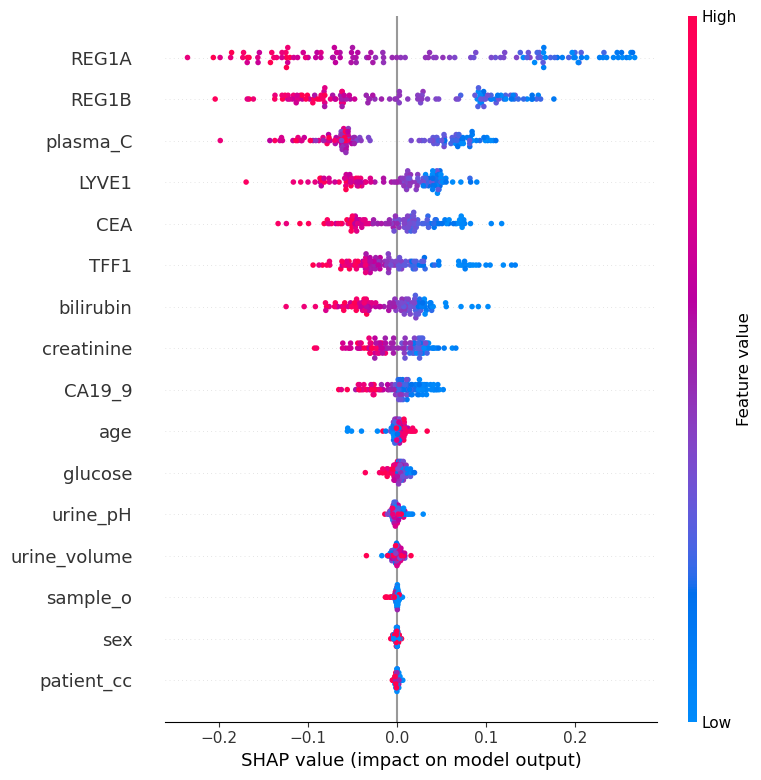

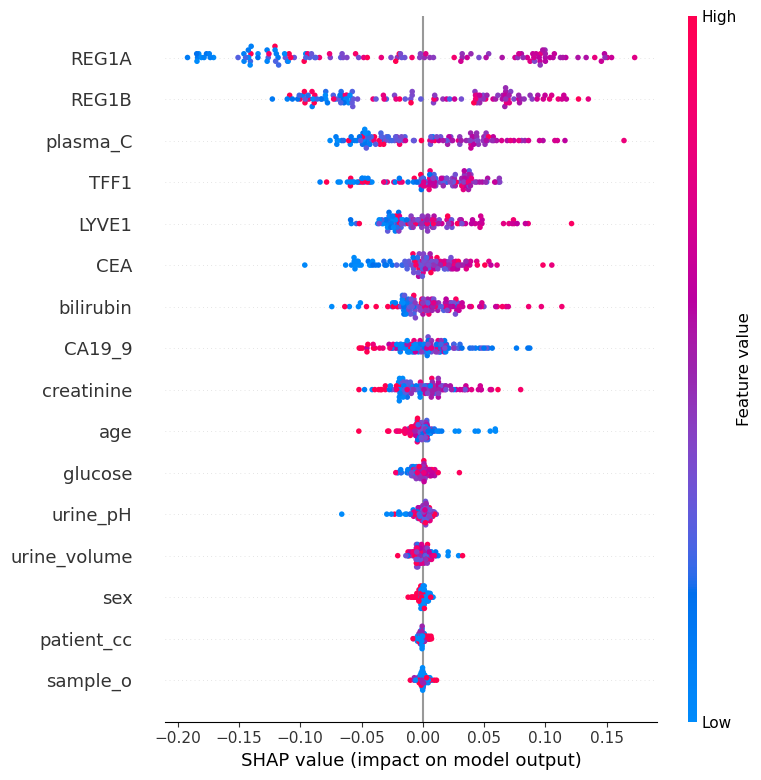

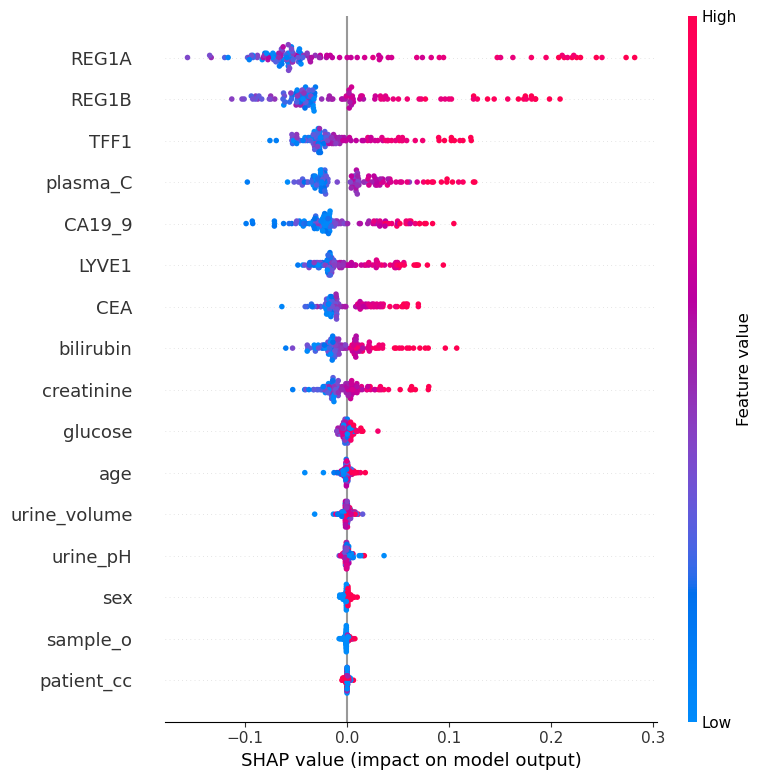

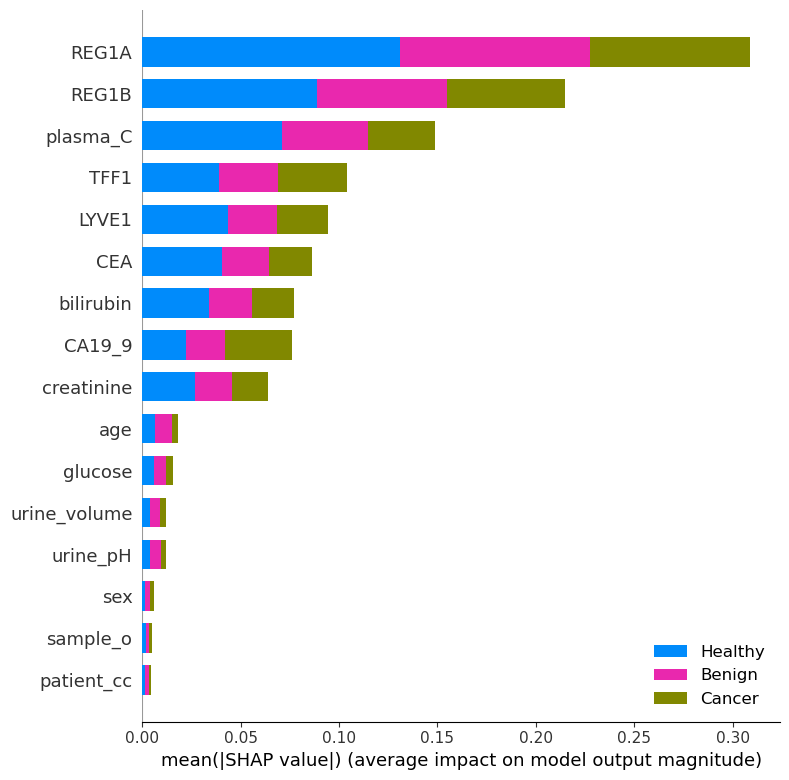

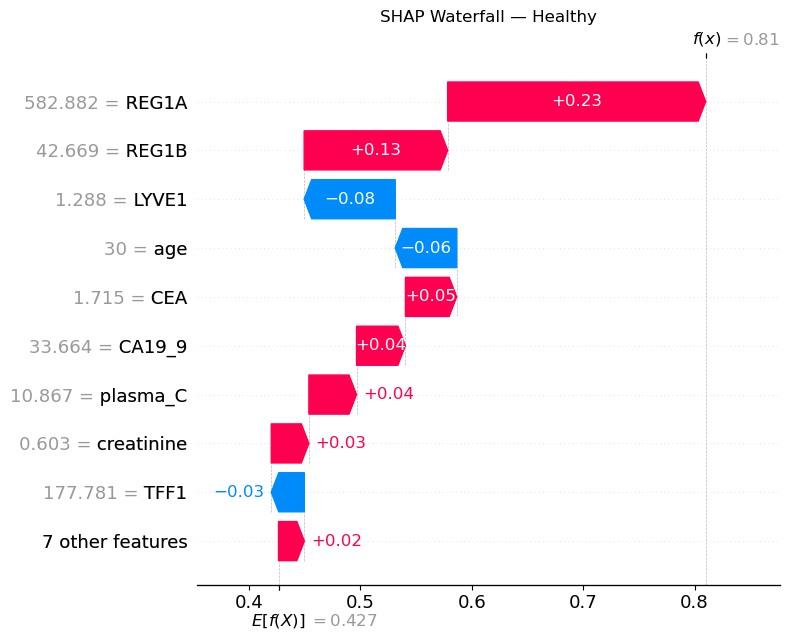

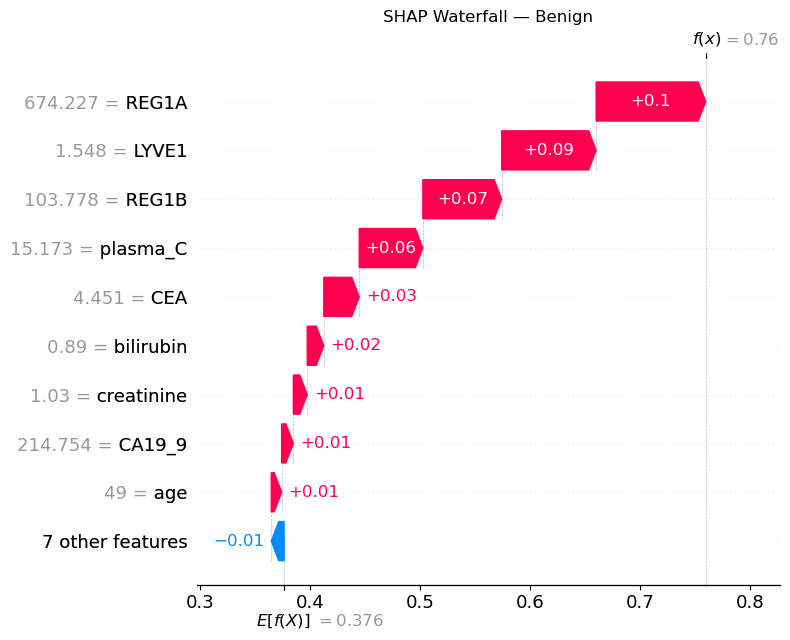

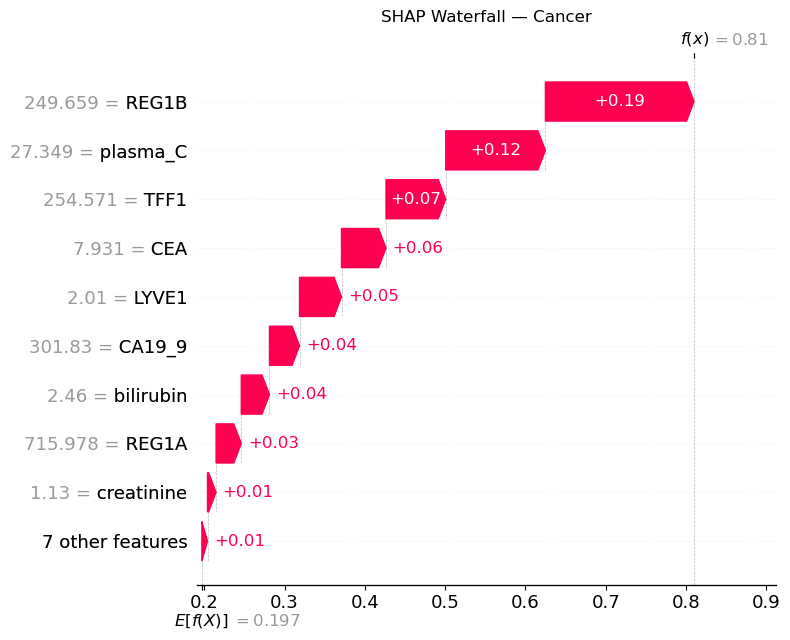

In [5]:
#shap
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

#Beeswarm per class 
for i, cls in enumerate(class_names):
    plt.figure()
    shap.summary_plot(
        shap_values[i], X_test,
        feature_names=feature_names,
        title=f'SHAP Summary — {cls}',
        show=False
    )
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/random_forest/shap_beeswarm_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

#Global bar 
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type='bar',
    class_names=class_names,
    show=False
)
plt.tight_layout()
plt.savefig('../plots/ds3/random_forest/shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

#Waterfall per class 
for i, cls in enumerate(class_names):
    idx = np.where(y_test == (i + 1))[0][0]
    shap.plots.waterfall(shap.Explanation(
        values = shap_values[i][idx],
        base_values  = explainer.expected_value[i],
        data = X_test.iloc[idx],
        feature_names= feature_names),
        show=False
    )
    plt.title(f'SHAP Waterfall — {cls}')
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/random_forest/shap_waterfall_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

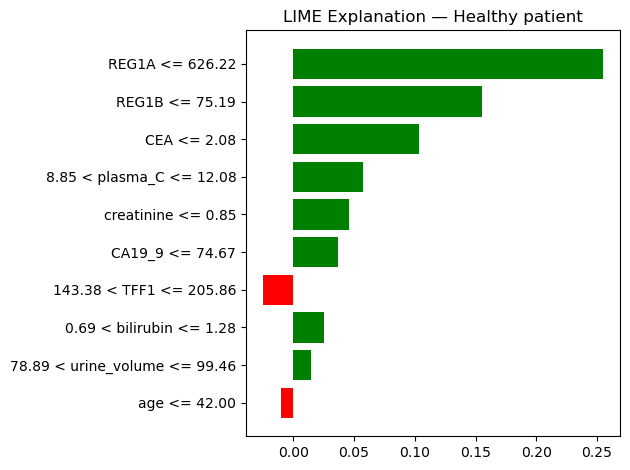

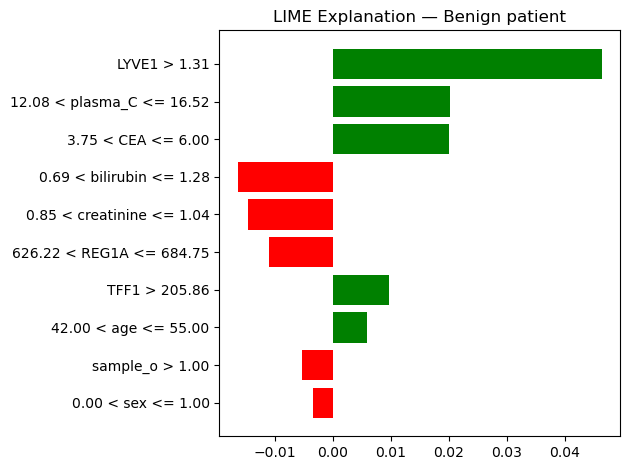

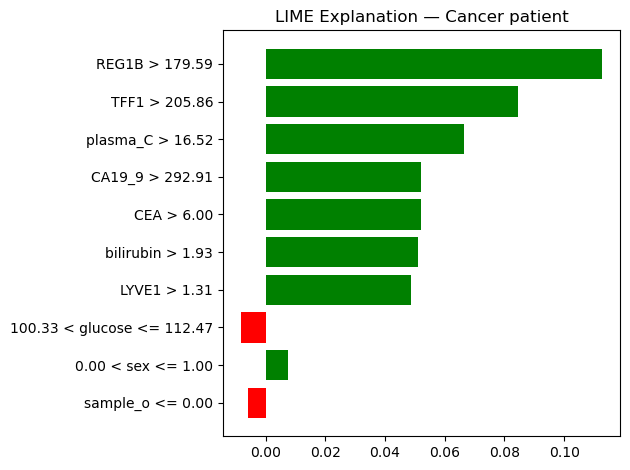

In [4]:
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', message='X does not have valid feature names')

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = feature_names,
    class_names    = class_names,
    mode           = 'classification',
    random_state   = 42
)

#one explanation per class
for i, cls in enumerate(class_names):
    idx = np.where(y_test == (i + 1))[0][0]
    
    exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        rf_model.predict_proba,
        num_features=10,
        labels=[i]
    )
    
    fig = exp.as_pyplot_figure(label=i)
    plt.title(f'LIME Explanation — {cls} patient')
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/random_forest/lime_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Dataset 3: SVM

  0%|          | 0/120 [00:00<?, ?it/s]

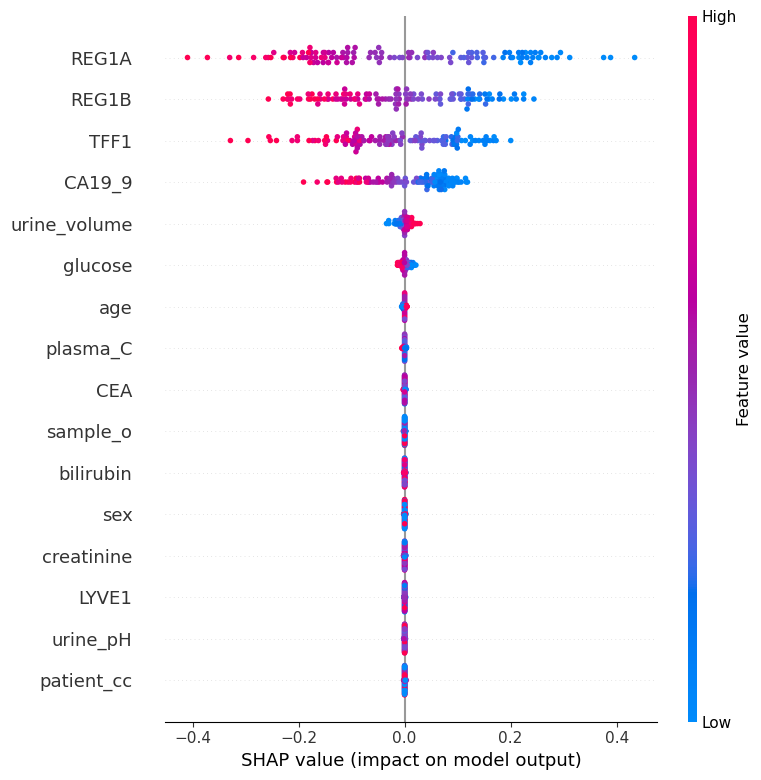

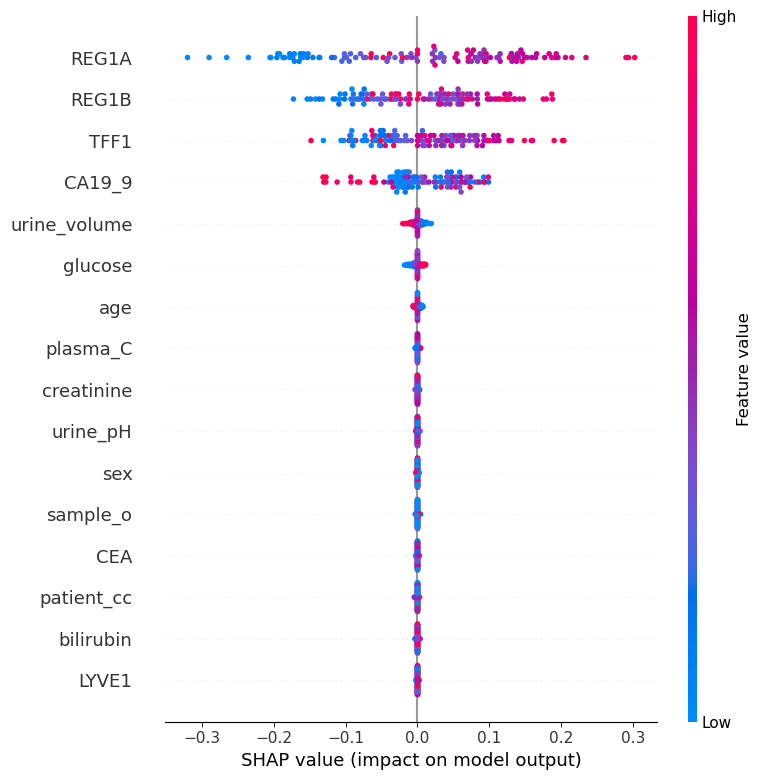

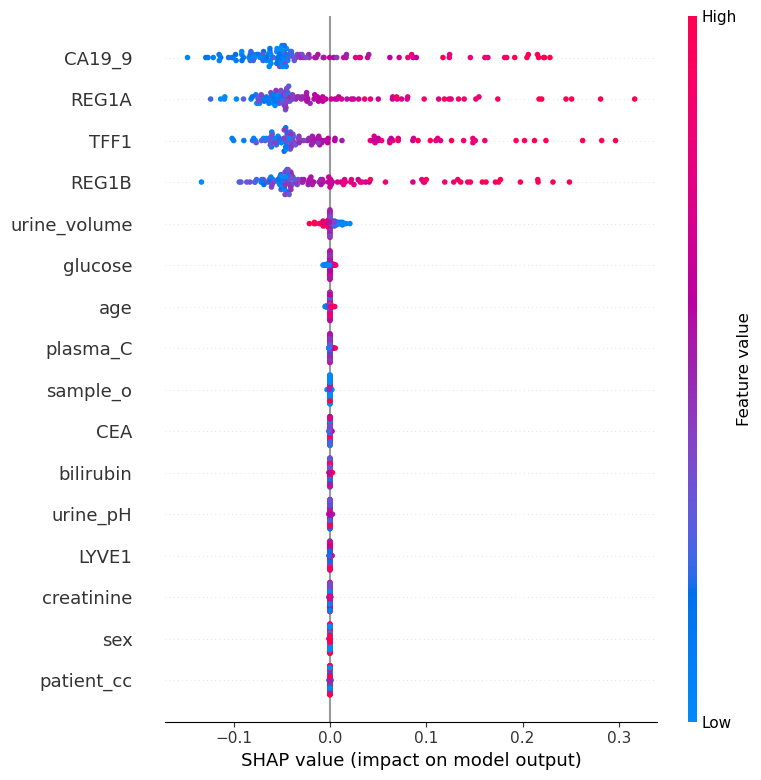

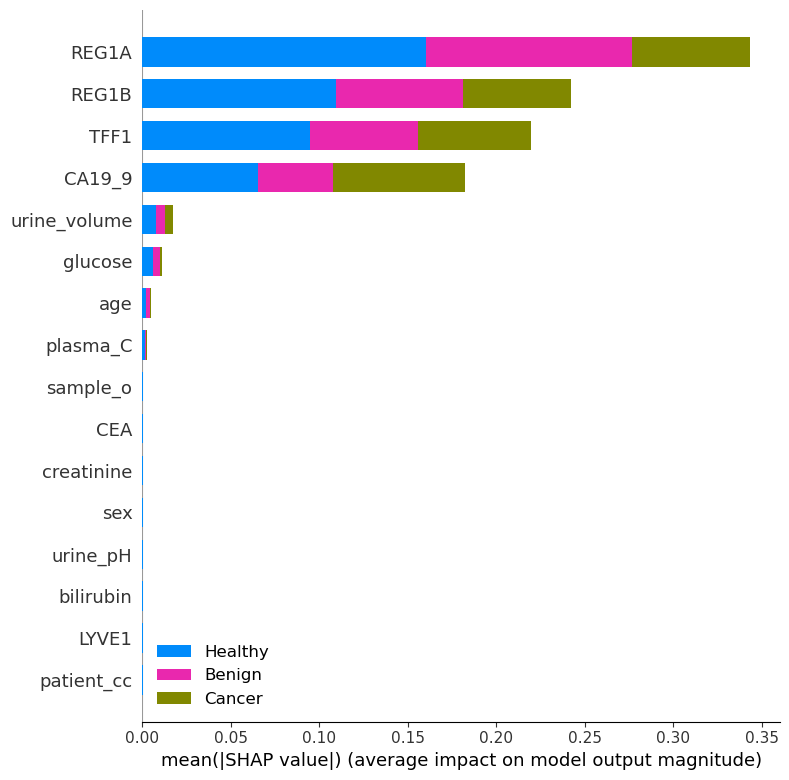

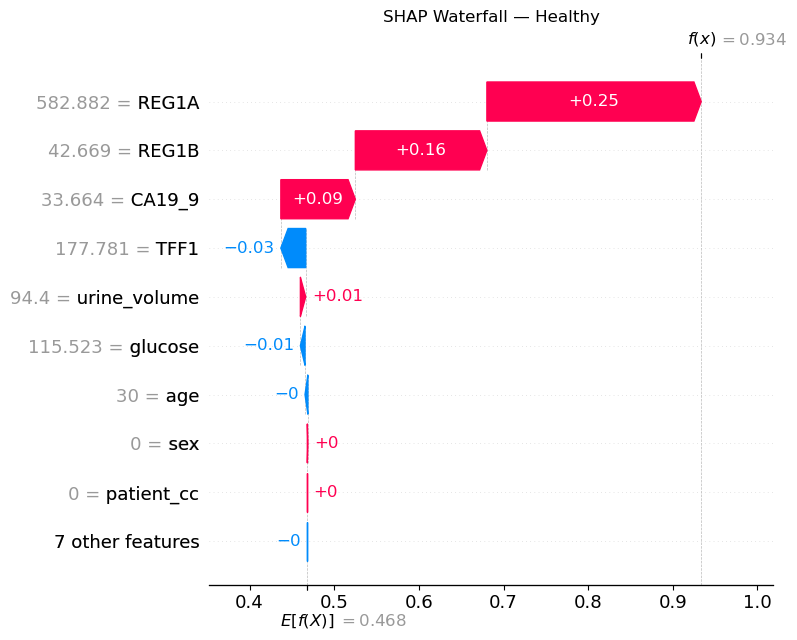

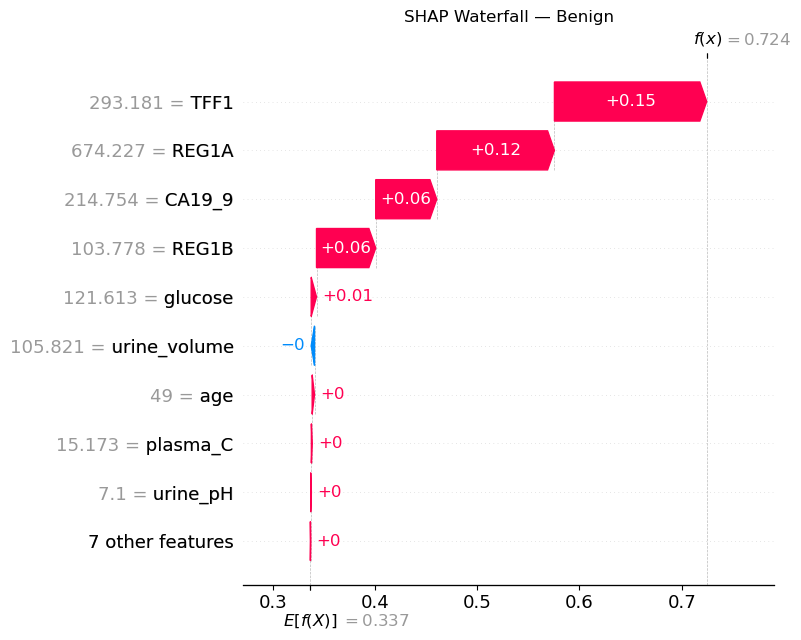

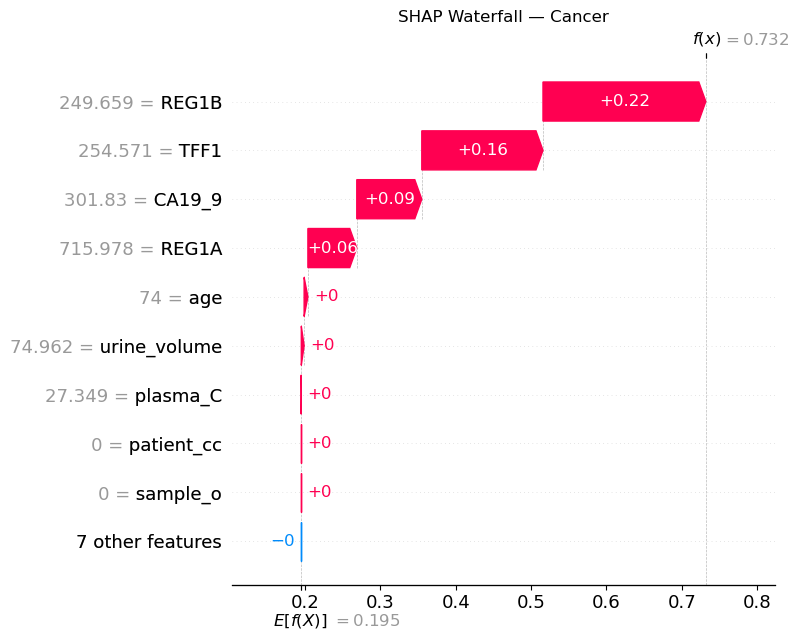

In [7]:
svm_model = joblib.load('../models/ds3/ds3_svm.pkl')

#shap
background  = shap.sample(X_train, 100)
explainer   = shap.KernelExplainer(svm_model.predict_proba, background)
shap_values = explainer.shap_values(X_test)  # this will take a few minutes

#Beeswarm per class 
for i, cls in enumerate(class_names):
    plt.figure()
    shap.summary_plot(
        shap_values[i], X_test,
        feature_names=feature_names,
        title=f'SHAP Summary — {cls}',
        show=False
    )
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/svm/shap_beeswarm_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

#Global bar 
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type='bar',
    class_names=class_names,
    show=False
)
plt.tight_layout()
plt.savefig('../plots/ds3/svm/shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

#Waterfall per class 
for i, cls in enumerate(class_names):
    idx = np.where(y_test == (i + 1))[0][0]
    shap.plots.waterfall(shap.Explanation(
        values       = shap_values[i][idx],
        base_values  = explainer.expected_value[i],
        data         = X_test.iloc[idx],
        feature_names= feature_names),
        show=False
    )
    plt.title(f'SHAP Waterfall — {cls}')
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/svm/shap_waterfall_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

X does not have valid feature names, but SVC was fitted with feature names


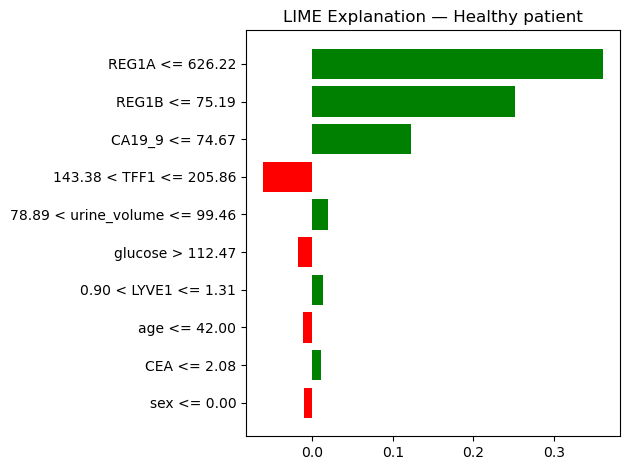

X does not have valid feature names, but SVC was fitted with feature names


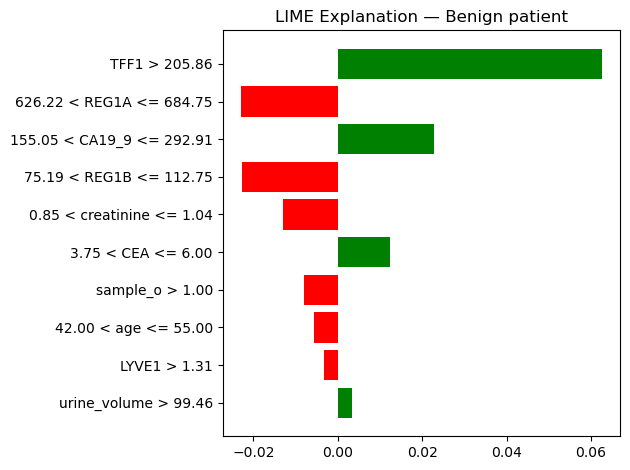

X does not have valid feature names, but SVC was fitted with feature names


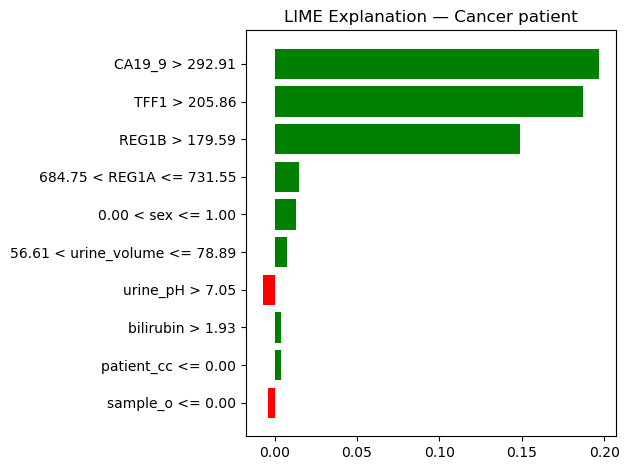

In [9]:
#lime
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = feature_names,
    class_names = class_names,
    mode = 'classification',
    random_state = 42
)

#one explanation per class
for i, cls in enumerate(class_names):
    idx = np.where(y_test == (i + 1))[0][0]
    
    exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        svm_model.predict_proba,
        num_features=10,
        labels=[i]
    )
    
    fig = exp.as_pyplot_figure(label=i)
    plt.title(f'LIME Explanation — {cls} patient')
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/svm/lime_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Dataset 3: MLP Classifier

  0%|          | 0/120 [00:00<?, ?it/s]

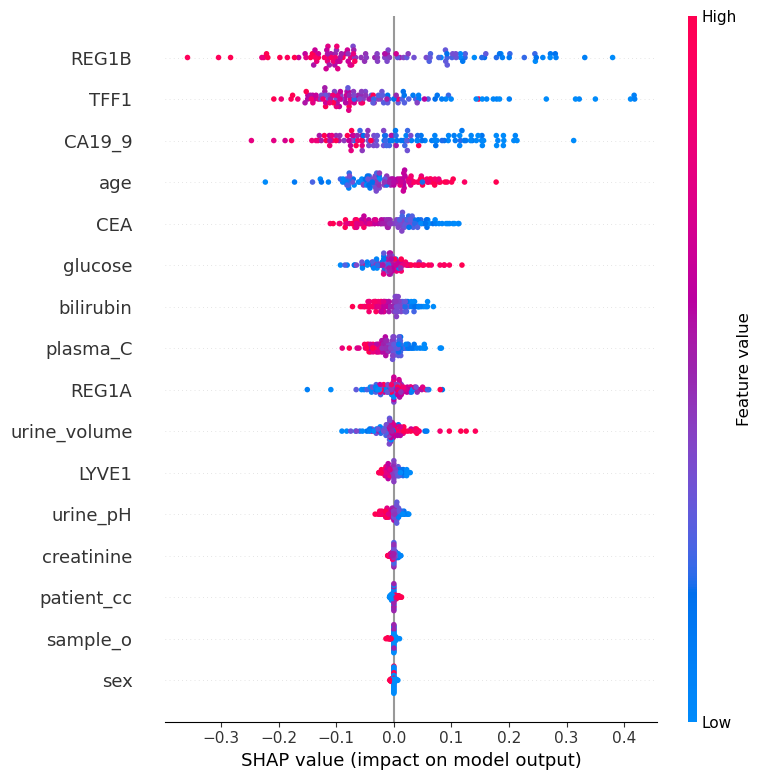

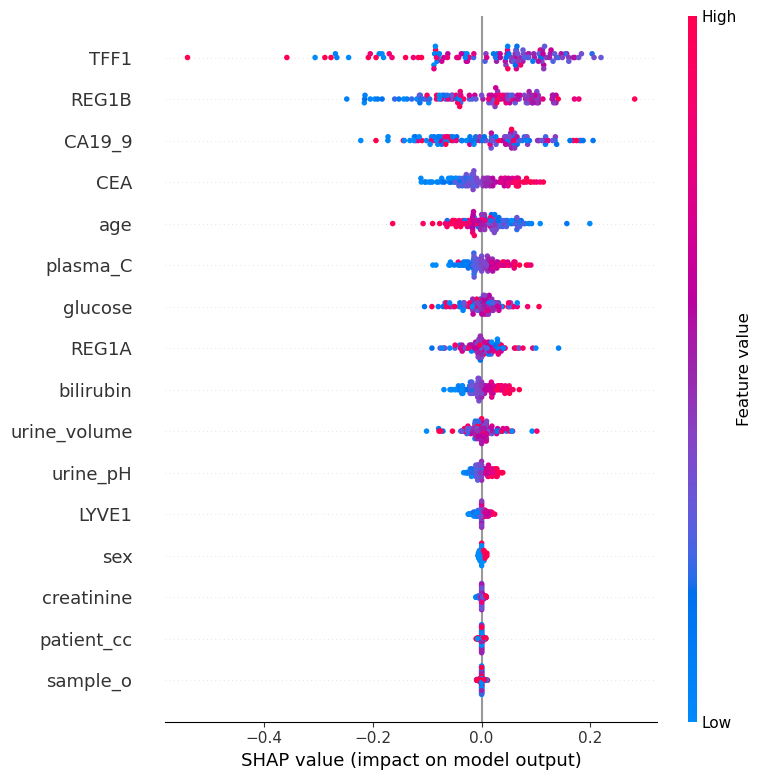

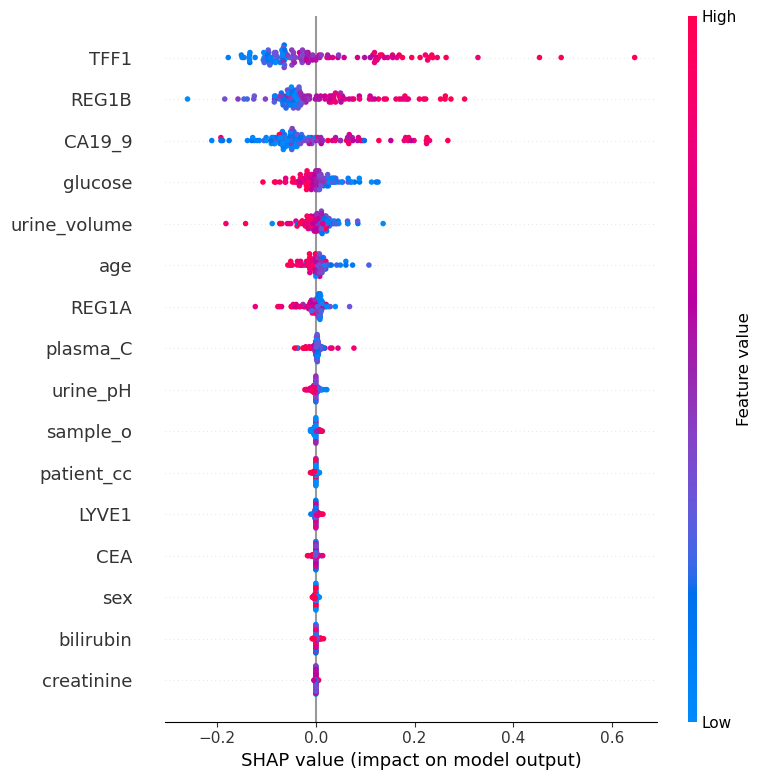

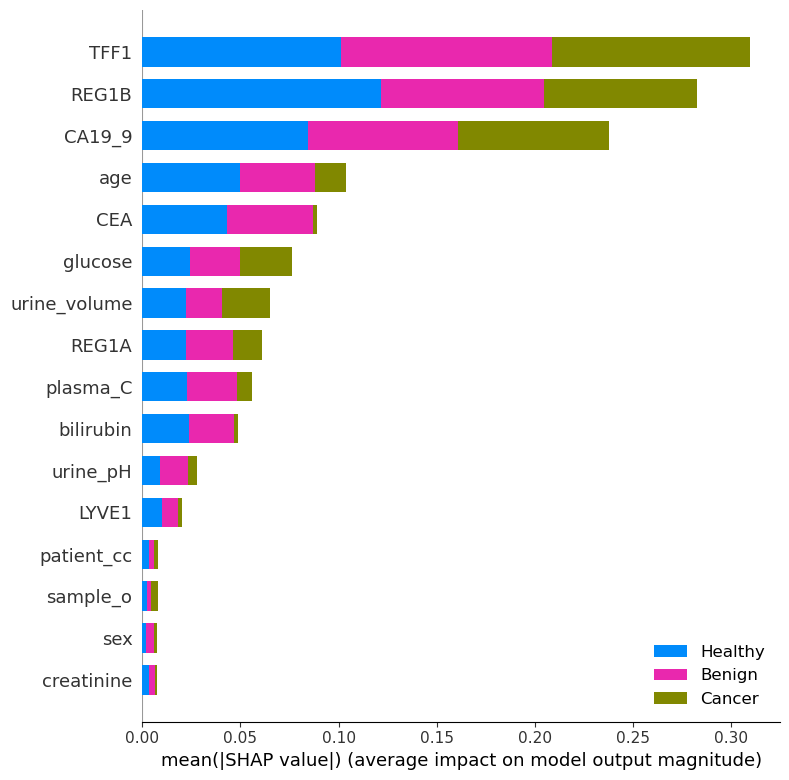

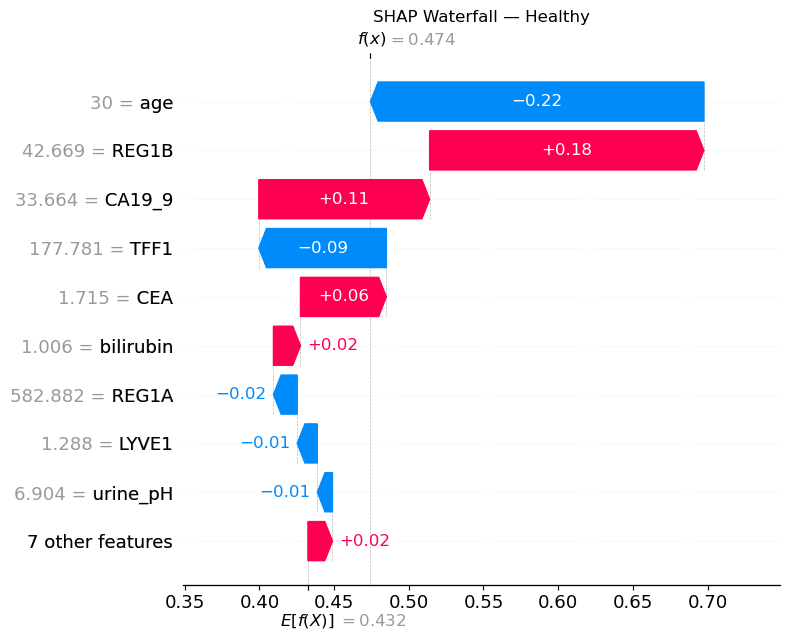

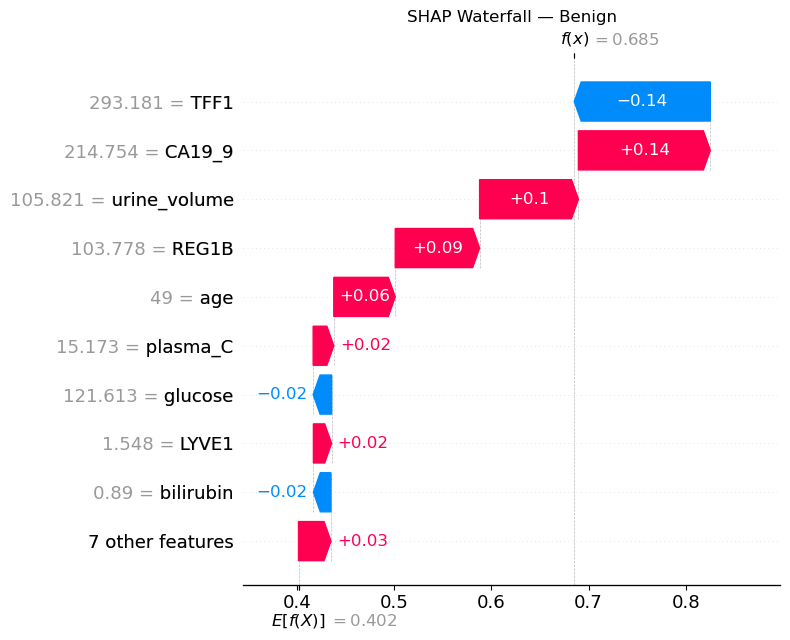

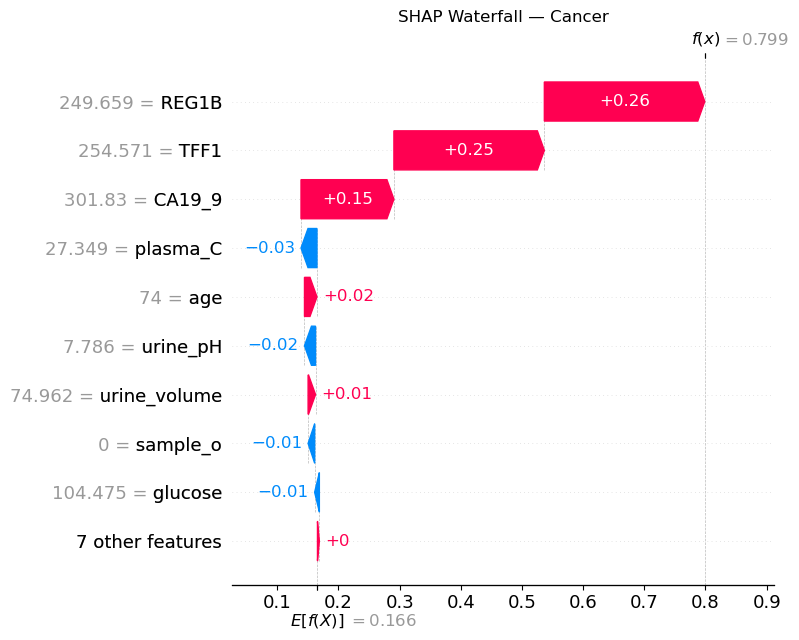

In [11]:
mlp_model = joblib.load('../models/ds3/ds3_mlp.pkl')

#shap
background  = shap.sample(X_train, 100)
explainer   = shap.KernelExplainer(mlp_model.predict_proba, background)
shap_values = explainer.shap_values(X_test)  # this will take a few minutes

#Beeswarm per class 
for i, cls in enumerate(class_names):
    plt.figure()
    shap.summary_plot(
        shap_values[i], X_test,
        feature_names=feature_names,
        title=f'SHAP Summary — {cls}',
        show=False
    )
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/mlp/shap_beeswarm_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

#Global bar 
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_type='bar',
    class_names=class_names,
    show=False
)
plt.tight_layout()
plt.savefig('../plots/ds3/mlp/shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

#Waterfall per class 
for i, cls in enumerate(class_names):
    idx = np.where(y_test == (i + 1))[0][0]
    shap.plots.waterfall(shap.Explanation(
        values       = shap_values[i][idx],
        base_values  = explainer.expected_value[i],
        data         = X_test.iloc[idx],
        feature_names= feature_names),
        show=False
    )
    plt.title(f'SHAP Waterfall — {cls}')
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/mlp/shap_waterfall_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

X does not have valid feature names, but MLPClassifier was fitted with feature names


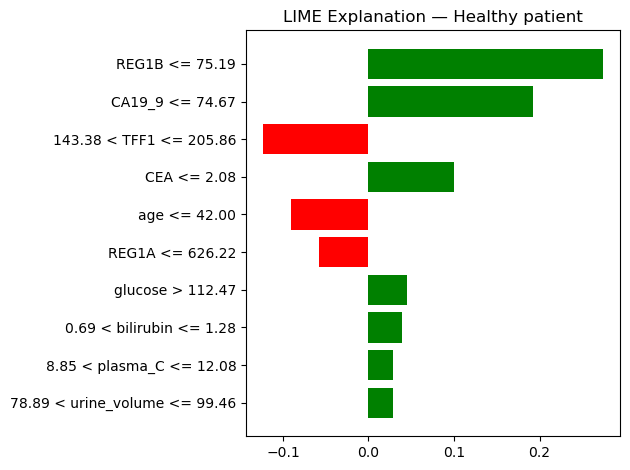

X does not have valid feature names, but MLPClassifier was fitted with feature names


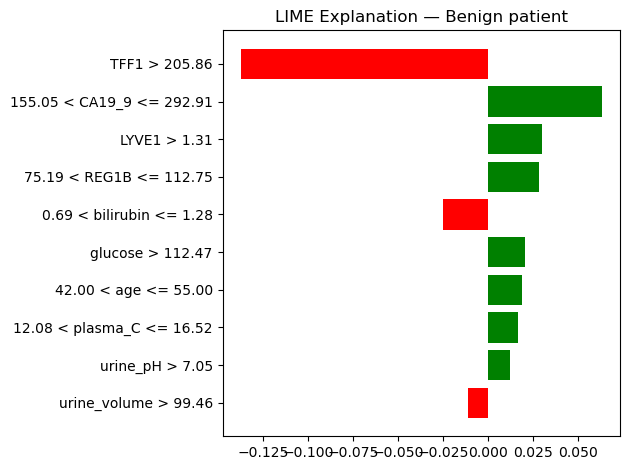

X does not have valid feature names, but MLPClassifier was fitted with feature names


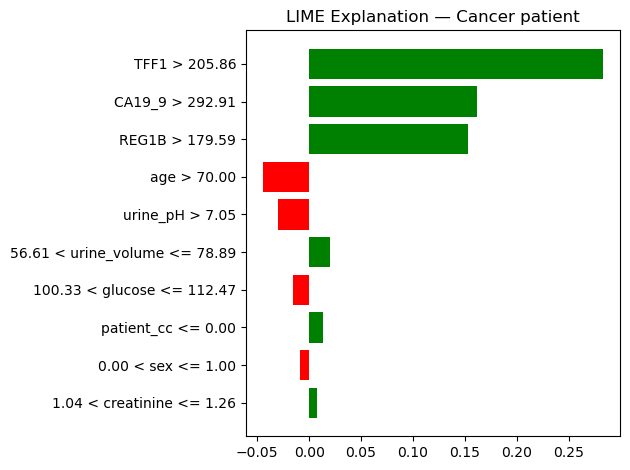

In [13]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = feature_names,
    class_names    = class_names,
    mode           = 'classification',
    random_state   = 42
)

#one explanation per class
for i, cls in enumerate(class_names):
    idx = np.where(y_test == (i + 1))[0][0]
    
    exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        mlp_model.predict_proba,
        num_features=10,
        labels=[i]
    )
    
    fig = exp.as_pyplot_figure(label=i)
    plt.title(f'LIME Explanation — {cls} patient')
    plt.tight_layout()
    plt.savefig(f'../plots/ds3/mlp/lime_{cls.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()